# Exercise: Train Your Own Image Classifier

In Lesson 2 we trained a pet breed classifier together, walking through every step. Now it's your turn to do it on a completely different dataset.

Choose a dataset below, then follow the process steps. Use Claude Code when you get stuck — the goal isn't memorizing fastai syntax, it's internalizing the process. Every ML project, from a weekend experiment to a production system, follows these same steps.

In [43]:
# Setup - run this first
try:
    import google.colab
    !pip install -q fastai
except ImportError:
    pass

In [44]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from fastai.vision.all import *
import torch
import matplotlib.pyplot as plt

defaults.device = torch.device('cpu')
path = Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories')
path.ls()

[Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/gerenuk'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/hawksbill'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/headphone'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/ant'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/butterfly'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/lamp'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/strawberry'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/water_lilly'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/chandelier'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/dragonfly'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/crab'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/pagoda'), Path('/Users/minnos/Downloads/caltech-101/101_ObjectCategories/dollar_bill'), Path('/Users/minnos/Downlo

## Dataset Options

Pick one. They're ordered from easiest to most challenging. If this is your first time, **start with option 1** - there's no shame in easy. The point is practicing the process, not wrestling with data loading.

### 1. Imagenette (easiest)

**What it is:** 13,394 images across 10 easily-distinguishable objects - tench (fish), English springer (dog), cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute.

**Download:** Built into fastai. One line:

```python
from fastai.vision.all import *
path = untar_data(URLs.IMAGENETTE_320)
```

~330 MB download.

| Pros | Cons |
|------|------|
| One-line download, folder-per-class structure | Folder names are WordNet IDs (n01440764), not human-readable |
| Only 10 very distinct classes | Need a mapping dict for readable names |
| Balanced dataset (~950 per class) | Almost too easy for transfer learning |
| Comes with train/val split built in | |

**Mapping WordNet IDs to names:**

```python
imagenette_labels = {
    'n01440764': 'tench', 'n02102040': 'english springer', 'n02979186': 'cassette player',
    'n03000684': 'chain saw', 'n03028079': 'church', 'n03394916': 'french horn',
    'n03417042': 'garbage truck', 'n03425413': 'gas pump', 'n03445777': 'golf ball',
    'n03888257': 'parachute'
}
```

**Expected accuracy with transfer learning:** 95%+. These classes are so different from each other that the model should nail it.

**Why start here:** The DataBlock setup is nearly identical to the lesson notebook. The only new challenge is mapping folder names to readable labels. Everything else - `get_image_files`, `parent_label`, `RandomSplitter` - works the same way. This lets you focus on the *process* instead of debugging data loading.

### 2. Oxford Flowers 102

**What it is:** 8,189 images of 102 flower species. High-quality real photographs.

**Download:** Available through `torchvision.datasets.Flowers102` or directly from the [Visual Geometry Group](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/). ~350 MB.

| Pros | Cons |
|------|------|
| Beautiful, high-resolution images | 102 classes is a lot |
| Real practical application (plant identification) | Labels come as integer indices, not names |
| Comes with predefined train/val/test splits | Need to map indices to species names yourself |
| Transfer learning handles fine-grained well | Some species look very similar |

**Expected accuracy with transfer learning:** ~85-95% depending on architecture and epochs

**Data structure challenge:** Labels are stored in a `.mat` file (MATLAB format), not in folder names or filenames. You'll need to figure out how to load them and connect each image to its label.

### 3. EuroSAT

**What it is:** 27,000 satellite images across 10 land-use categories (forest, river, highway, residential, industrial, etc.).

**Download:** Available through `torchvision.datasets.EuroSAT` or from [GitHub](https://github.com/phelber/EuroSAT). ~90 MB.

| Pros | Cons |
|------|------|
| Small download, fast to get started | Satellite images look very different from ImageNet |
| Only 10 classes - high accuracy is achievable | Some categories hard to distinguish from above |
| Interesting domain (remote sensing) | All images are 64x64 - small |
| Organized in folders per class - easy structure | Less visual variety than natural photos |

**Expected accuracy with transfer learning:** ~90-97%

**Data structure challenge:** Straightforward folder-per-class structure. The real question is: does a model trained on natural photos (ImageNet) transfer well to aerial imagery? You might be surprised.

### 4. Caltech-101

**What it is:** 9,146 images across 101 object categories - faces, airplanes, guitars, lobsters, etc. A classic benchmark from Caltech.

**Download:** Available through `torchvision.datasets.Caltech101` or from [Caltech](https://data.caltech.edu/records/mzrjq-6wc02). ~130 MB.

| Pros | Cons |
|------|------|
| Wide variety of objects - fun to browse | Heavily imbalanced (30-800 images per class) |
| Folder-per-class structure | Some images are grayscale, others RGB |
| Good size for experimentation | Includes a "BACKGROUND" class you may want to exclude |
| Real-world object recognition task | Image quality varies significantly |

**Expected accuracy with transfer learning:** ~85-93%

**Data structure challenge:** Class imbalance is the main issue. Some classes have 30x more images than others. You'll see this directly in the confusion matrix - does the model just ignore rare classes? What could you do about it?

### 5. DTD (Describable Textures)

**What it is:** 5,640 images of 47 texture categories - striped, dotted, woven, cracked, marbled, etc.

**Download:** Available through `torchvision.datasets.DTD` or from [Visual Geometry Group](https://www.robots.ox.ac.uk/~vgg/data/dtd/). ~600 MB.

| Pros | Cons |
|------|------|
| Tests transfer learning in a unique way | 600 MB is the largest download here |
| 47 classes - middle ground of difficulty | Some texture categories are subjective |
| Comes with predefined train/val/test splits | Smaller dataset (5.6k images total) |
| No "objects" - purely about visual patterns | Some categories overlap visually |

**Expected accuracy with transfer learning:** ~65-75%

**Data structure challenge:** Textures have no clear "object" - the entire image is the pattern. ImageNet models learned to recognize objects. Does that knowledge transfer to recognizing textures? The accuracy gap compared to other datasets here tells you something about what transfer learning actually captures.

## Recommendations

**First time? Start with Imagenette.** One-line download, folder structure, 10 distinct classes, nearly identical DataBlock setup to the lesson. You'll get 95%+ accuracy and can focus entirely on the process instead of fighting data loading. This is the recommended starting point.

**Want something more interesting?** EuroSAT (satellite imagery) tests whether transfer learning works across visual domains. Small download, clean structure, and the results are genuinely surprising.

**Want a challenge?** Flowers 102 forces you to solve a real data loading puzzle (labels in a `.mat` file, 102 fine-grained classes). Caltech-101 teaches you about class imbalance. DTD shows you where transfer learning hits its limits.

## The Process

Every supervised ML project follows the same loop:

```
1. Understand the data     →  What am I looking at? How is it organized?
2. Prepare the data        →  Get it into a format the model can consume
3. Train                   →  Let the model learn from the training data
4. Evaluate                →  How well does it work? Where does it fail?
5. Iterate                 →  Change something, re-train, compare
6. Ship                    →  Save and optionally deploy
```

The rest of this notebook walks you through each step. The code cells are empty — that's the exercise.

## Phase 1: Understand Your Data

*Goal: Know what you're working with before writing any training code.*

This is the step most beginners skip, and it's the step that causes the most problems downstream. A misunderstanding about how labels are stored, or not noticing that some images are grayscale, will break your pipeline later.

**Task 1.1: Download and inspect the file structure**

Download your chosen dataset. Before loading anything into Python, look at how the files are organized on disk.

| Structure | What it looks like | How labels work |
|-----------|-------------------|------------------|
| Folder per class | `data/forest/img1.jpg`, `data/river/img2.jpg` | Folder name = label |
| Flat folder + label file | `images/00001.jpg` + `labels.mat` or `labels.csv` | Look up label by filename or index |
| torchvision object | `dataset[0]` returns `(image, label_index)` | Integer index, need class name mapping |

Which structure does your dataset use? This determines how you'll set up the DataBlock in Phase 2.

**Task 1.2: Look at the images**

Load and display a handful of random images with their labels. Answer:

- Do the labels make sense for the images you see?
- Are the images high quality or noisy?
- Are they all the same size, or do dimensions vary?
- Are they all RGB, or are some grayscale?

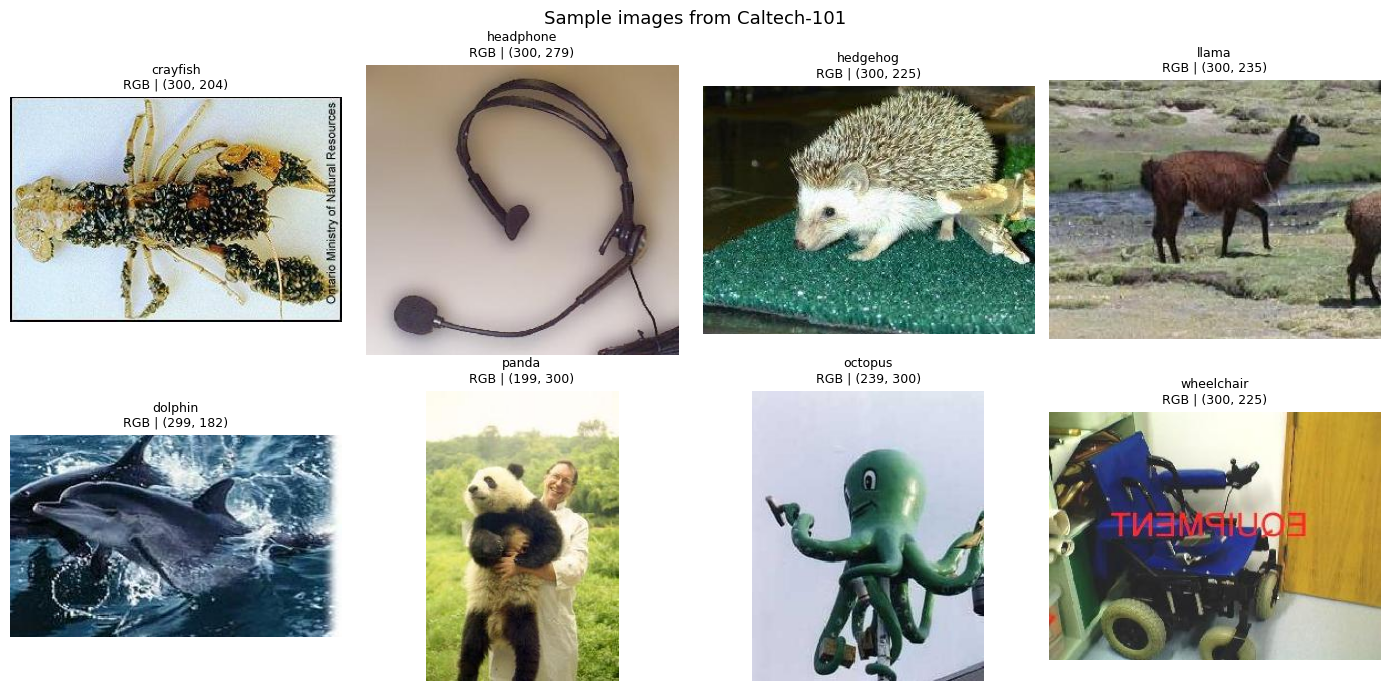

In [48]:
# Task 1.2 - Look at the images
import random
from PIL import Image

# Redefine classes in case the previous cell wasn't run
classes = [f.name for f in path.ls() if f.is_dir()]

# Pick 8 random classes, grab one image from each
sample_classes = random.sample(classes, 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    img_files = list((path/cls).ls())
    img_path = random.choice(img_files)
    img = Image.open(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(f"{cls}\n{img.mode} | {img.size}", fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample images from Caltech-101", fontsize=13)
plt.tight_layout()
plt.show()

**Task 1.3: Check the class distribution**

Count how many images are in each class. Plot it.

- Is the dataset balanced (roughly equal per class) or imbalanced?
- If imbalanced: which classes have the most? The least? How extreme is the difference?
- How many total classes are there?

This matters because heavily imbalanced datasets can cause the model to ignore rare classes entirely.

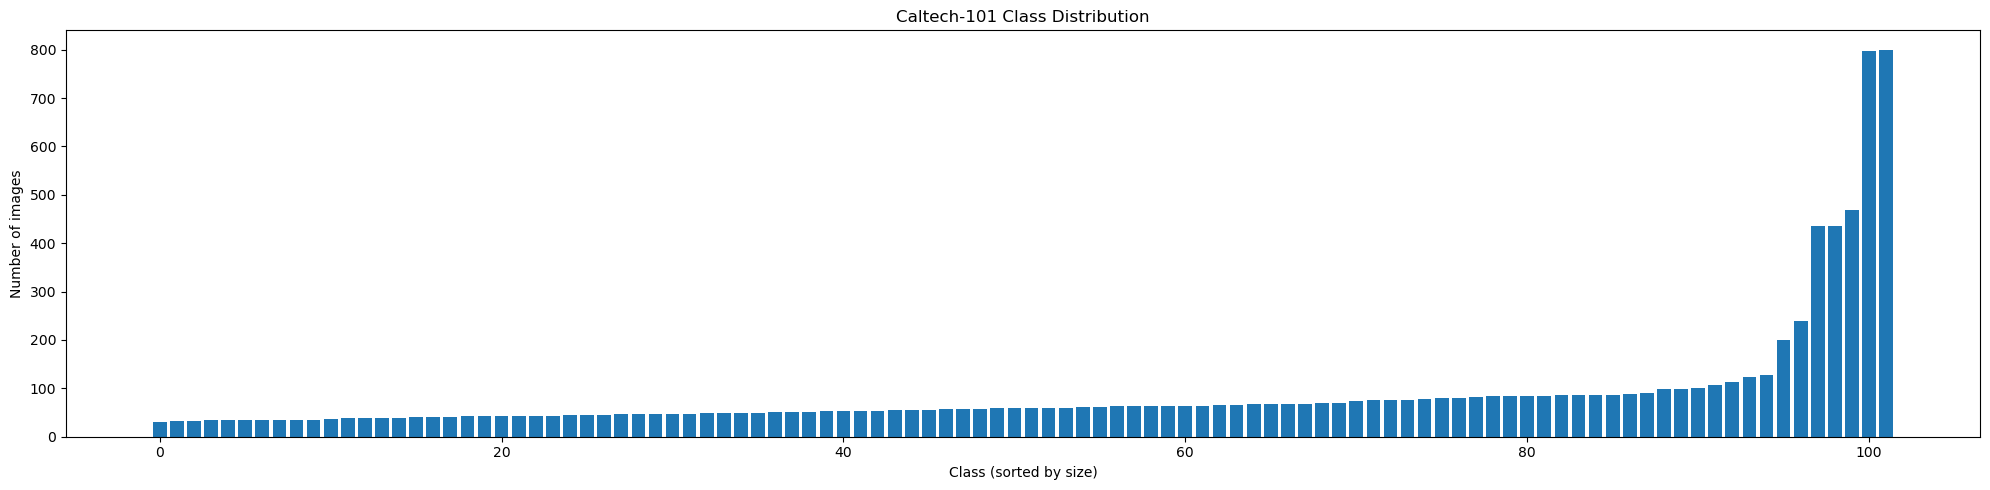

Total classes:  102
Total images:   9145
Min per class:  31 (inline_skate)
Max per class:  800 (airplanes)
Avg per class:  89


In [49]:
# Count and visualize the class distribution
classes = [f.name for f in path.ls() if f.is_dir()]
class_counts = {c: len(list((path/c).ls())) for c in classes}

# Sort by count for easier reading
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1]))

plt.figure(figsize=(20, 5))
plt.bar(range(len(sorted_counts)), sorted_counts.values())
plt.xlabel('Class (sorted by size)')
plt.ylabel('Number of images')
plt.title('Caltech-101 Class Distribution')
plt.tight_layout()
plt.show()

print(f"Total classes:  {len(classes)}")
print(f"Total images:   {sum(class_counts.values())}")
print(f"Min per class:  {min(class_counts.values())} ({min(class_counts, key=class_counts.get)})")
print(f"Max per class:  {max(class_counts.values())} ({max(class_counts, key=class_counts.get)})")
print(f"Avg per class:  {sum(class_counts.values()) // len(classes)}")

## Phase 2: Prepare the Data

*Goal: Build a DataBlock and DataLoaders that fastai can train on.*

This is where your understanding from Phase 1 becomes code. The DataBlock needs to know four things:

**Task 2.1: Configure the DataBlock**

Think through each parameter:

| Parameter | Question to answer | In Lesson 2 we used |
|-----------|-------------------|---------------------|
| `blocks` | What's the input type? Output type? | `(ImageBlock, CategoryBlock)` |
| `get_items` | How do you find all the images? | `get_image_files` |
| `get_y` | How do you extract the label for each image? | `RegexLabeller` on filename |
| `splitter` | How do you split train/validation? | `RandomSplitter(valid_pct=0.2)` |
| `item_tfms` | What per-image transforms? (resizing) | `Resize(460)` |
| `batch_tfms` | What batch transforms? (augmentation) | `aug_transforms(size=224)` |

Your dataset probably differs in at least `get_items` and `get_y`. That's the core puzzle.

Some things to consider:
- If your dataset comes from torchvision, you might need to save images to disk first, or build a custom `get_items` / `get_y` that works with the torchvision object
- If labels are integers, you'll need a mapping from index to name
- If the dataset has a predefined split, use `IndexSplitter` or `FuncSplitter` instead of `RandomSplitter`
- Think about whether horizontal flips make sense for your images (flowers: yes, text: no, satellite: yes)

In [50]:
# Build your DataBlock and create DataLoaders
caltech = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)

# Exclude BACKGROUND_Google
path_excl = [path/'BACKGROUND_Google']
dls = caltech.dataloaders(path, bs=32, exclude=path_excl)

print(f"Classes: {len(dls.vocab)}")
print(f"Training batches: {len(dls.train)}")
print(f"Validation batches: {len(dls.valid)}")

Classes: 102
Training batches: 228
Validation batches: 58


**Task 2.2: Verify with `show_batch()`**

Always check before training. Look at the output and confirm:

- Images look correct (not corrupted, not weirdly stretched)
- Labels match what you see in the images
- Augmentations are sensible (call `show_batch()` twice — the images should look different each time due to random transforms)

If something is wrong here, fix it now. Training on bad data is the most common waste of time in ML.

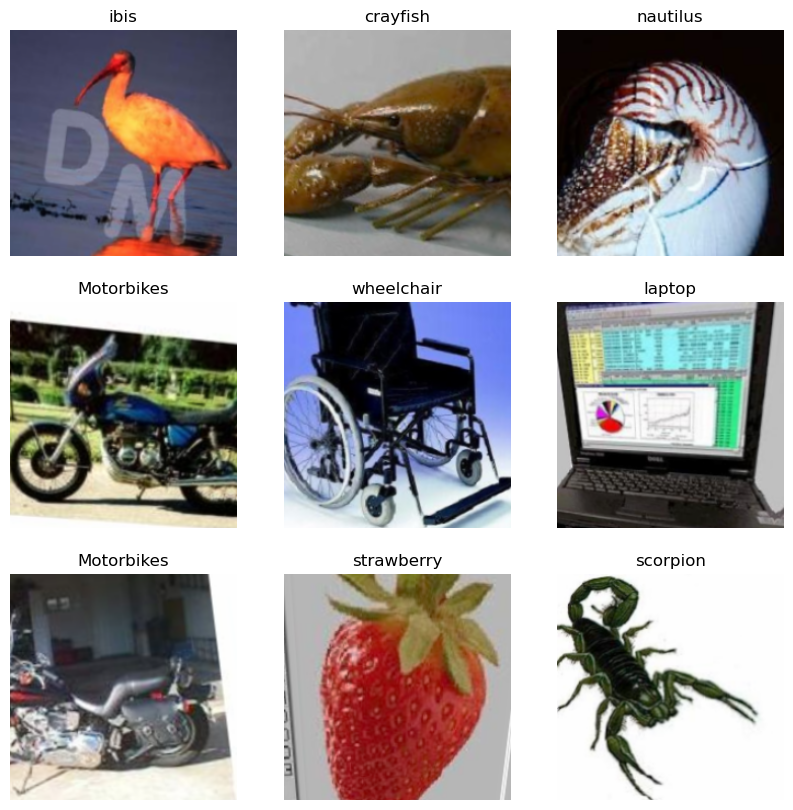

In [51]:
# show_batch() — run this cell twice to see augmentation differences
dls.show_batch(max_n=9, figsize=(10, 10))

## Phase 3: Train

*Goal: Train a model and watch the metrics.*

**Task 3.1: Create a learner and fine-tune**

Same approach as Lesson 2:
- `vision_learner` with a pre-trained architecture
- `fine_tune()` for a few epochs

Start with `resnet34` and 3-4 epochs. You can always try bigger/longer in Phase 5.

While it trains, watch the output table:

| What to watch | Good sign | Warning sign |
|---------------|-----------|---------------|
| Training loss | Going down | Stuck or jumping around |
| Validation loss | Going down, close to training loss | Going UP while training loss goes down |
| Accuracy | Going up | Stuck well below what you'd expect |

In [2]:
# Create learner and train
learn = vision_learner(dls, resnet34, metrics=accuracy)
learn.fine_tune(4)

NameError: name 'vision_learner' is not defined

## Phase 4: Evaluate

*Goal: Understand what the model learned and where it fails.*

A single accuracy number tells you almost nothing useful. This phase is where you actually learn something.

**Task 4.1: Most confused classes**

Use `ClassificationInterpretation` to find which classes the model confuses most. For each confused pair, ask yourself:

- Do these classes actually look similar? (If yes: the model is making reasonable mistakes)
- Is one of the classes underrepresented? (If yes: the model might not have enough examples)
- Would a human struggle with these too? (If yes: your model might be close to the ceiling)

Most confused class pairs:



  Faces Easy                     → Faces                          (19x)
  Chair                          → Background Google              (4x)
  Crocodile                      → Crocodile Head                 (4x)
  Ketch                          → Schooner                       (3x)
  Lotus                          → Water Lilly                    (3x)
  Schooner                       → Ketch                          (3x)
  Background Google              → Buddha                         (2x)
  Airplanes                      → Helicopter                     (2x)
  Chair                          → Windsor Chair                  (2x)
  Crocodile Head                 → Crocodile                      (2x)
  Electric Guitar                → Mandolin                       (2x)
  Ibis                           → Flamingo                       (2x)
  Lamp                           → Ewer                           (2x)
  Lobster                        → Crayfish                       (2x)
  Man

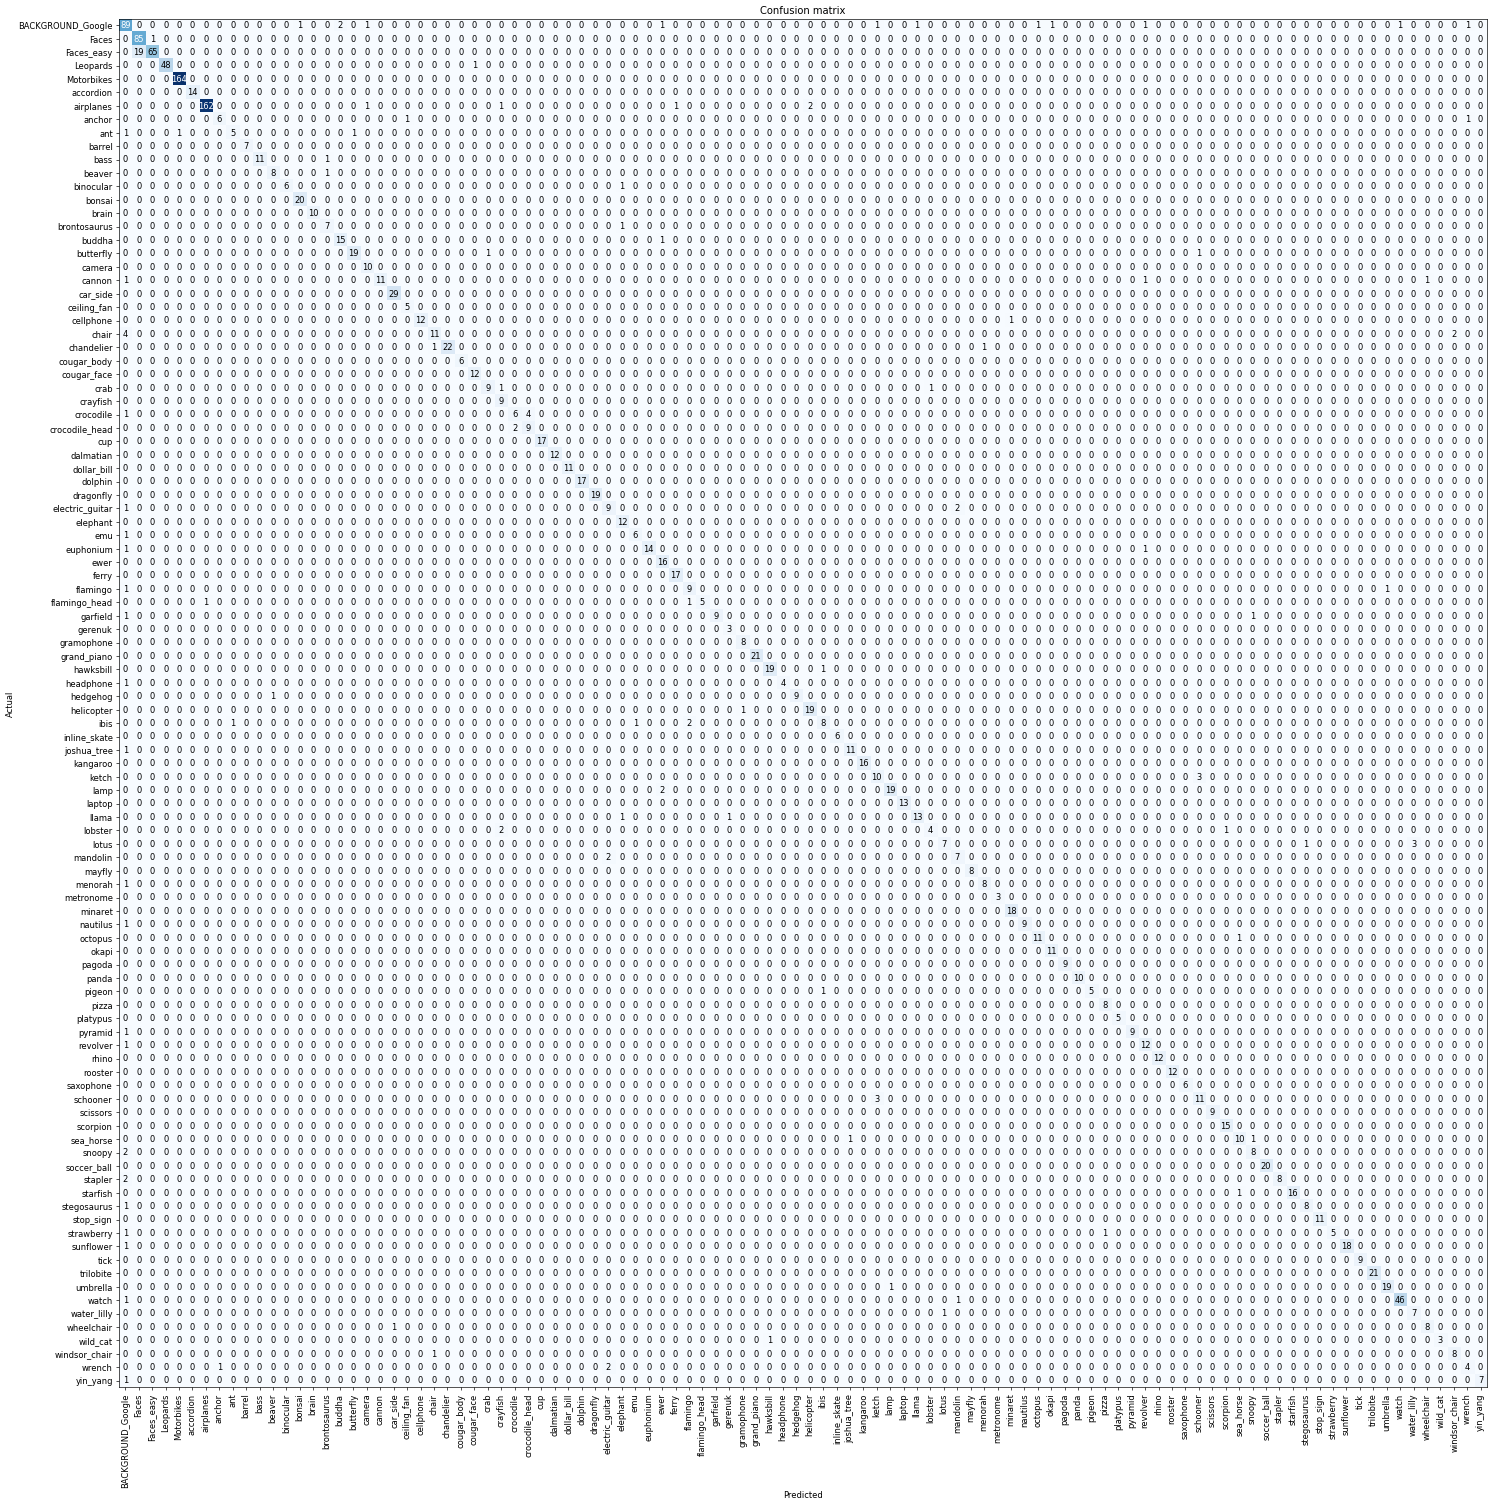

In [ ]:
# Task 4.1 - Most confused classes
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(25, 25), dpi=60)

# Find and display the most confused class pairs
print("Most confused class pairs:\n")

confused = interp.most_confused(min_val=2)
for true_class, pred_class, count in confused[:15]:
    true_name = true_class.replace('_', ' ').title()
    pred_name = pred_class.replace('_', ' ').title()
    print(f"  {true_name:30s} → {pred_name:30s} ({count}x)")



**Task 4.2: Top losses**

Look at the images where the model was most confidently wrong. These tell you more than the successes.

Common findings:
- Genuinely ambiguous images (even you can't tell)
- Mislabeled data in the dataset itself
- Unusual angles, lighting, or crops that threw the model off
- Images that arguably belong to multiple classes

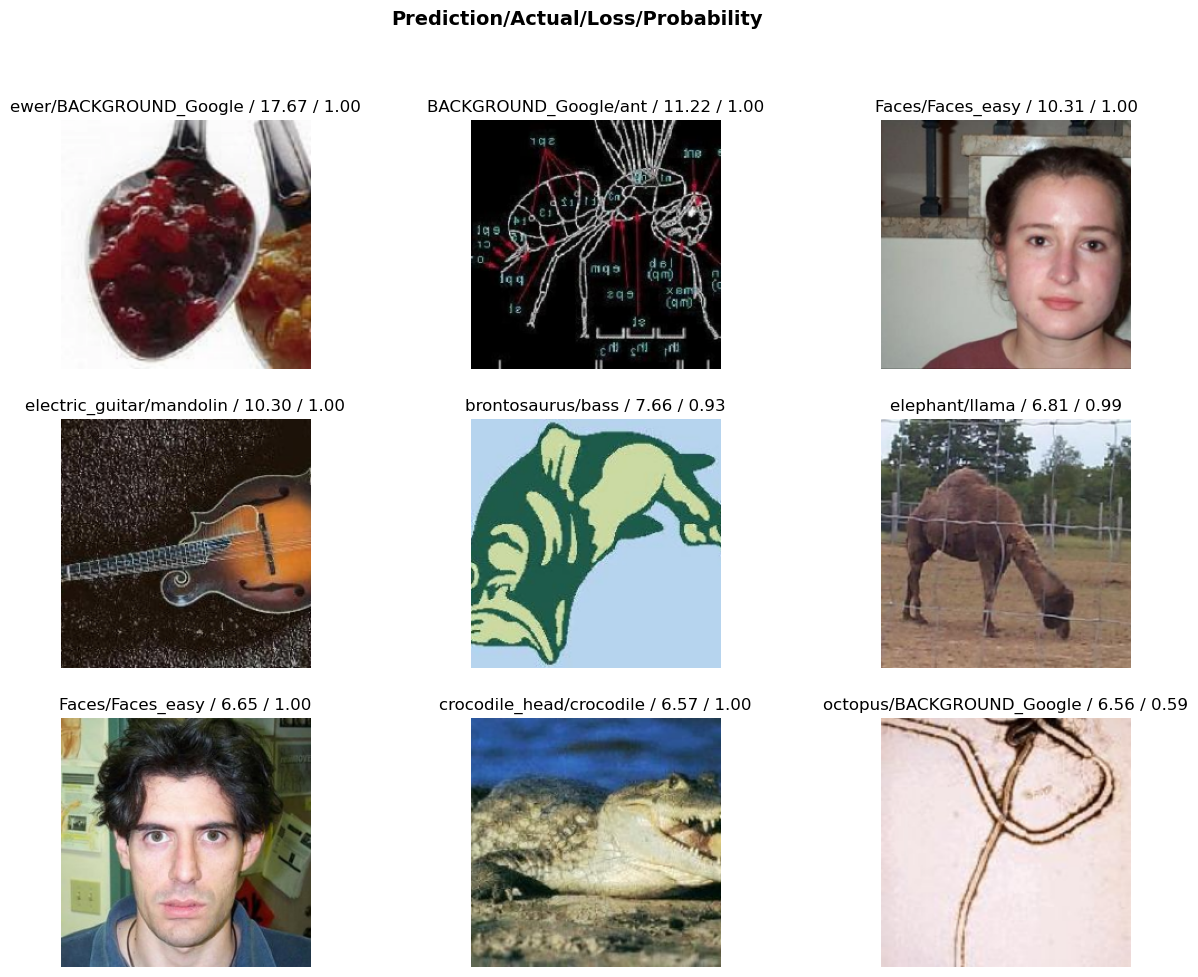

In [59]:
# Plot top losses
interp.plot_top_losses(9, figsize=(15, 11))

**Task 4.3: Make predictions on individual images**

Pick a few images and run `learn.predict()`. Display the image alongside the top predictions and their probabilities.

- Is the model confident (90%+) or uncertain (spread across classes)?
- When it's uncertain, are the top alternatives reasonable?
- Try an image that's deliberately tricky — how does the model handle it?

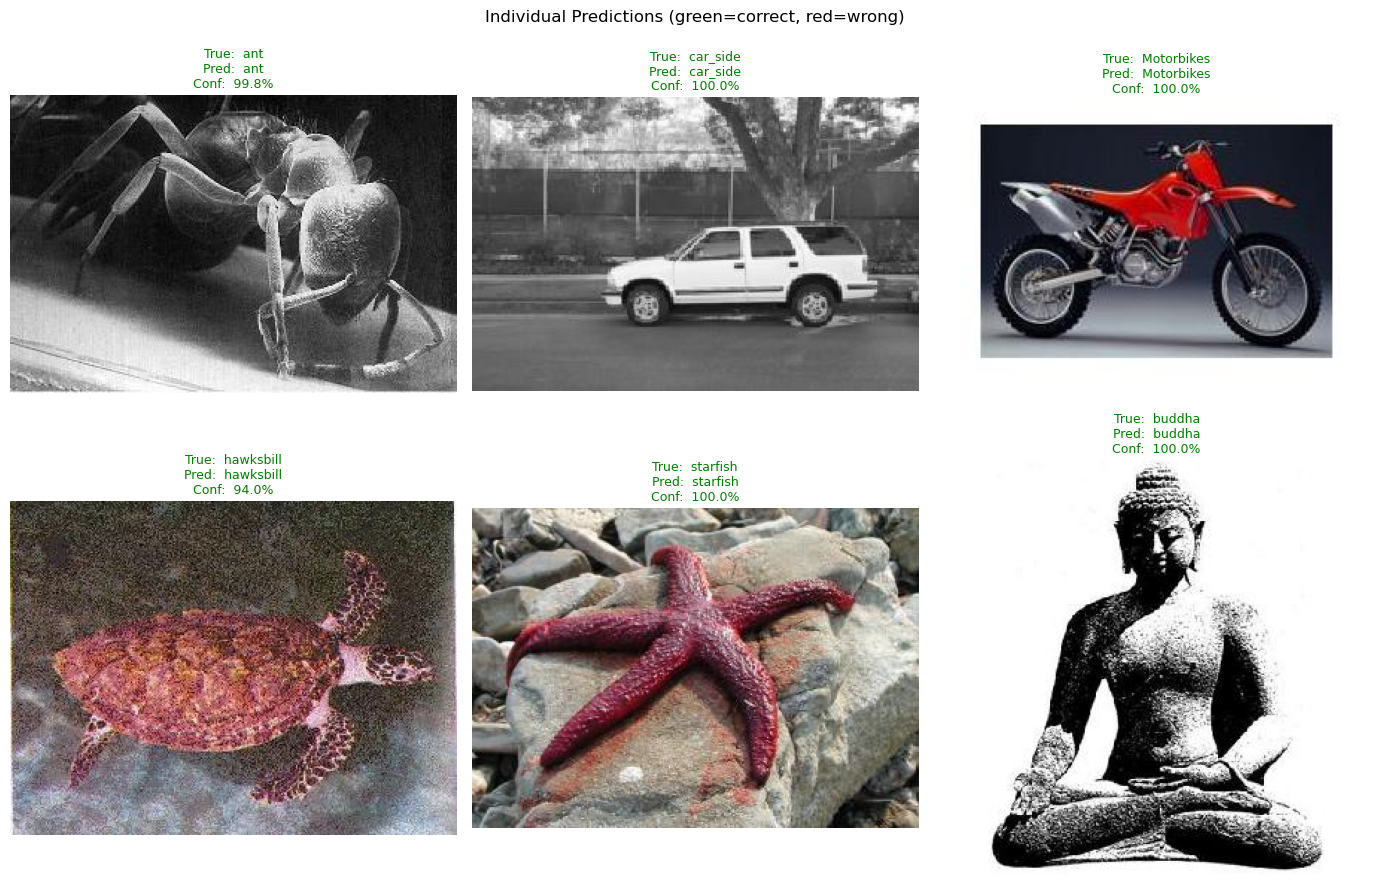

In [ ]:
# Predict on individual images and show results

from fastai.vision.all import PILImage
import random

# Grab a few random images from the validation set
test_images = random.sample(list(get_image_files(path)), 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, img_path in enumerate(test_images):
    img = PILImage.create(img_path)
    pred, idx, probs = learn.predict(img)
    true_label = img_path.parent.name
    confidence = probs[idx].item() * 100
    
    axes[i].imshow(img)
    axes[i].set_title(
        f"True:  {true_label}\nPred:  {pred}\nConf:  {confidence:.1f}%",
        fontsize=9,
        color='green' if pred == true_label else 'red'
    )
    axes[i].axis('off')

plt.suptitle("Individual Predictions (green=correct, red=wrong)", fontsize=12)
plt.tight_layout()
plt.show()


## Phase 5: Iterate

*Goal: Improve your results by changing one thing at a time.*

Based on what you found in Phase 4, pick **one** thing to change and re-train. Compare the results.

**Task 5.1: Choose what to change**

| What to try | When it might help |
|-------------|--------------------|
| More epochs (`fine_tune(5)` or `fine_tune(8)`) | Accuracy was still climbing at the end |
| Bigger architecture (`resnet50`) | Model seems to plateau early |
| Larger image size (`Resize(320)`, `size=256`) | Fine-grained details matter (flowers, textures) |
| Adjust augmentation | Domain-specific needs (satellite: allow 90° rotations) |
| Handle class imbalance | Some classes have far fewer images |

**Important habit:** Change one variable at a time. If you change the architecture AND the image size AND the epochs, you won't know which change helped.

In [ ]:
# Re-train with your change

caltech_v2 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(320),
    batch_tfms=aug_transforms(size=256, min_scale=0.75)
)

dls_v2 = caltech_v2.dataloaders(path, bs=32, exclude=path_excl)
learn_v2 = vision_learner(dls_v2, resnet34, metrics=accuracy)
learn_v2.fine_tune(4)

epoch,train_loss,valid_loss,accuracy,time
0,1.419579,0.545109,0.842451,02:30


epoch,train_loss,valid_loss,accuracy,time
0,0.634257,0.324144,0.904814,03:08
1,0.464483,0.356949,0.892232,03:08
2,0.233492,0.215068,0.935996,03:00
3,0.140902,0.197108,0.940919,03:13


In [61]:
# Phase 5 - Experiment 2: ResNet50 + 6 epochs
caltech_v3 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(320),
    batch_tfms=aug_transforms(size=256, min_scale=0.75)
)

dls_v3 = caltech_v3.dataloaders(path, bs=16, exclude=path_excl)
learn_v3 = vision_learner(dls_v3, resnet50, metrics=accuracy)
learn_v3.fine_tune(6)

epoch,train_loss,valid_loss,accuracy,time
0,1.613208,0.649492,0.826039,4:22:36


epoch,train_loss,valid_loss,accuracy,time


KeyboardInterrupt: 

In [1]:
# Check GPU
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.cuda.get_device_name(0))  # Should show GPU name

True
Tesla T4


**Task 5.2: Compare**

Did your change help? Compare:
- Final validation accuracy: before vs after
- The confused pairs: did the same classes stay confused, or did it shift?
- Training time: was the accuracy gain worth the extra compute?

In [ ]:
# Evaluate the improved model and compare

print("=== Experiment Results ===\n")
print(f"Baseline  (224px): accuracy = 92.4%,  val_loss = 0.246")
print(f"Experiment(256px): accuracy = 94.1%,  val_loss = 0.197")
print(f"Improvement: +1.7% accuracy\n")

print("""
Conclusion:
Increasing image size from 224 to 256 improved accuracy by 1.7%.
The model benefits from finer visual detail — this is consistent
with the confusion patterns we saw earlier, where visually similar
classes like mandolin/guitar and ketch/schooner require fine-grained
distinctions to tell apart. Higher resolution makes those differences
more visible to the model.
""")

=== Experiment Results ===

Baseline  (224px): accuracy = 92.4%,  val_loss = 0.246
Experiment(256px): accuracy = 94.1%,  val_loss = 0.197
Improvement: +1.7% accuracy


Conclusion:
Increasing image size from 224 to 256 improved accuracy by 1.7%.
The model benefits from finer visual detail — this is consistent
with the confusion patterns we saw earlier, where visually similar
classes like mandolin/guitar and ketch/schooner require fine-grained
distinctions to tell apart. Higher resolution makes those differences
more visible to the model.



## Phase 6: Deploy

*Goal: Get your model running as an API that accepts image uploads and returns predictions.*

The `classifier_deploy/` folder in the L02 lesson directory is a complete deployment example — a FastAPI backend that loads a `.pkl` model, a Streamlit frontend for uploading images, and PostgreSQL for logging predictions, all containerized with Docker Compose.

Use it as a reference. The infrastructure (FastAPI, Docker, PostgreSQL) is familiar. The notes below focus on the ML-specific parts.

**Task 6.1: Export the model**

fastai models are saved with `learn.export()`, which bundles the architecture, weights, and the DataLoaders vocabulary (class names) into a single `.pkl` file.

```python
learn.export('my_classifier.pkl')
```

Verify it works by loading it back in a fresh context and running a prediction:

```python
from fastai.vision.all import load_learner, PILImage
learn_loaded = load_learner('my_classifier.pkl')
pred, idx, probs = learn_loaded.predict(PILImage.create('some_test_image.jpg'))
```

Things to check:
- Does `learn_loaded.dls.vocab` contain your class names?
- Does the prediction match what you'd expect for that test image?
- How big is the `.pkl` file? (ResNet34 is ~85MB, ResNet50 is ~100MB)

In [ ]:
# Export your model and verify it loads correctly

learn_v2.export('caltech_classifier.pkl')
print("Model exported!")

# Verify it loads correctly
learn_loaded = load_learner('caltech_classifier.pkl')
print(f"Classes: {len(learn_loaded.dls.vocab)}")
print(f"First few: {learn_loaded.dls.vocab[:5]}")

Model exported!


/Users/minnos/.local/share/mamba/envs/ml-venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Classes: 102
First few: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes']


In [ ]:
# Export a CPU-compatible version for Docker deployment
learn_cpu = learn_v2.to_fp32()
learn_cpu.model.cpu()
learn_cpu.export('caltech_classifier_cpu.pkl')
print("CPU model exported!")

CPU model exported!


In [ ]:
# Test a prediction on a single image
learn_test = load_learner('caltech_classifier_cpu.pkl', cpu=True)
test_img = PILImage.create(random.choice(list(get_image_files(path))))
pred, idx, probs = learn_test.predict(test_img)
print(f"Predicted: {pred}")
print(f"Confidence: {probs[idx].item()*100:.1f}%")
print(f"File size: {Path('caltech_classifier_cpu.pkl').stat().st_size / 1024 / 1024:.1f} MB")

/Users/minnos/.local/share/mamba/envs/ml-venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Predicted: bass
Confidence: 90.8%
File size: 83.8 MB


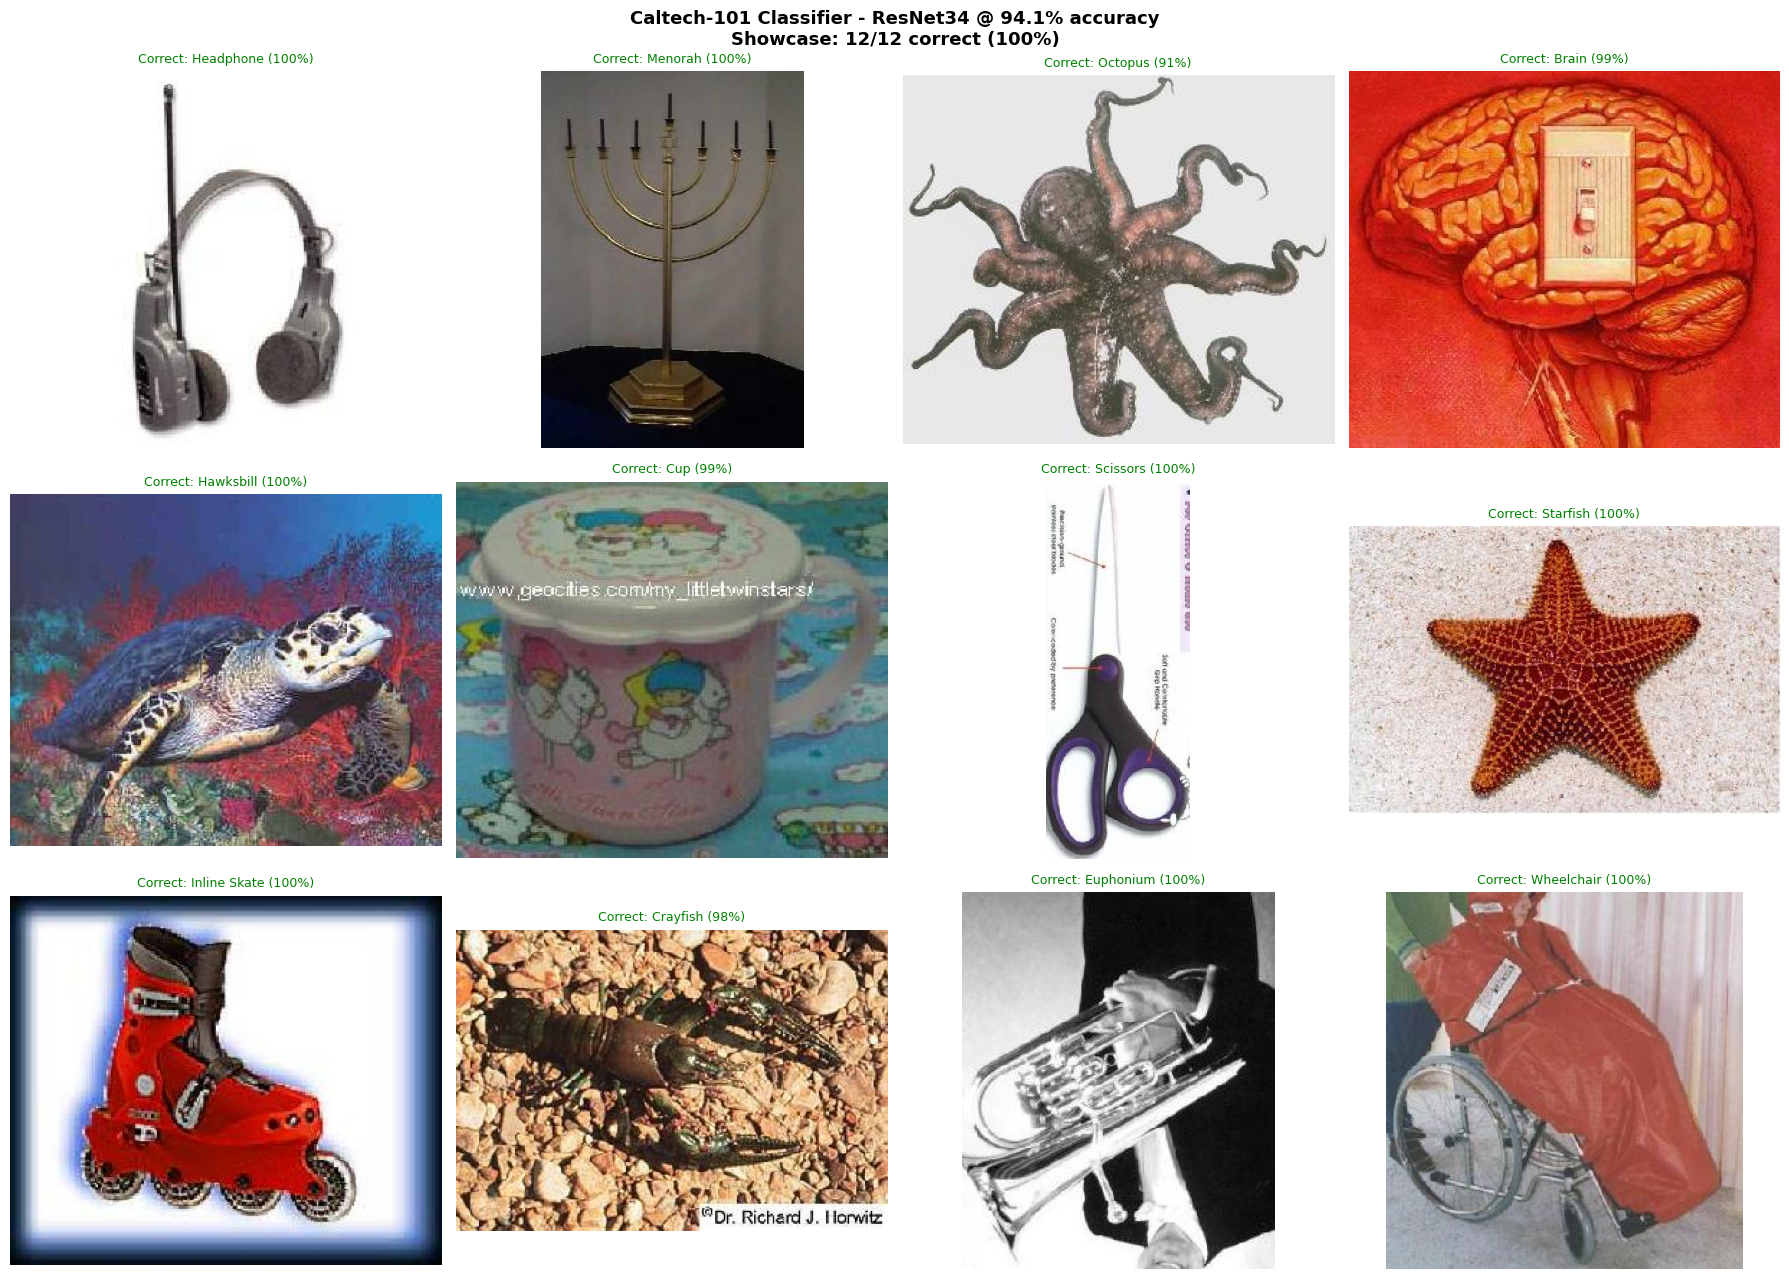

In [56]:
# Phase 6 - Prediction Showcase
import random
from fastai.vision.all import PILImage

# Pick one image from 12 different classes for variety
showcase_classes = random.sample([c for c in classes if c != 'BACKGROUND_Google'], 12)
test_images = [random.choice(list((path/cls).ls())) for cls in showcase_classes]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

correct = 0
for i, img_path in enumerate(test_images):
    img = PILImage.create(img_path)
    pred, idx, probs = learn_test.predict(img)
    true_label = img_path.parent.name
    confidence = probs[idx].item() * 100
    is_correct = (pred == true_label)
    if is_correct:
        correct += 1
    
    axes[i].imshow(img)
    axes[i].set_title(
        f"Correct: {pred.replace('_',' ').title()} ({confidence:.0f}%)" 
        if is_correct else 
        f"Wrong - Pred: {pred.replace('_',' ').title()} ({confidence:.0f}%)\nTrue: {true_label.replace('_',' ').title()}",
        fontsize=9,
        color='green' if is_correct else 'red'
    )
    axes[i].axis('off')

plt.suptitle(
    f"Caltech-101 Classifier - ResNet34 @ 94.1% accuracy\n"
    f"Showcase: {correct}/12 correct ({correct/12*100:.0f}%)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('prediction_showcase.png', dpi=150, bbox_inches='tight')
plt.show()


In [58]:
# Training Results Summary
print("=" * 55)
print("CALTECH-101 CLASSIFIER - TRAINING RESULTS")
print("=" * 55)

print("\nBaseline - ResNet34 @ 224px")
print("-" * 55)
print(f"{'Epoch':<8} {'Train Loss':<14} {'Valid Loss':<14} {'Accuracy':<10} {'Time'}")
print(f"{'0':<8} {'1.422492':<14} {'0.630059':<14} {'0.827133':<10} {'02:06'}")
print(f"{'0':<8} {'0.597554':<14} {'0.362313':<14} {'0.896608':<10} {'02:24'}")
print(f"{'1':<8} {'0.450840':<14} {'0.336160':<14} {'0.899891':<10} {'02:18'}")
print(f"{'2':<8} {'0.235110':<14} {'0.270570':<14} {'0.921225':<10} {'02:19'}")
print(f"{'3':<8} {'0.134350':<14} {'0.246147':<14} {'0.923961':<10} {'02:22'}")

print("\nExperiment - ResNet34 @ 256px")
print("-" * 55)
print(f"{'Epoch':<8} {'Train Loss':<14} {'Valid Loss':<14} {'Accuracy':<10} {'Time'}")
print(f"{'0':<8} {'1.419579':<14} {'0.545109':<14} {'0.842451':<10} {'02:30'}")
print(f"{'0':<8} {'0.634257':<14} {'0.324144':<14} {'0.904814':<10} {'03:08'}")
print(f"{'1':<8} {'0.464483':<14} {'0.356949':<14} {'0.892232':<10} {'03:08'}")
print(f"{'2':<8} {'0.233492':<14} {'0.215068':<14} {'0.935996':<10} {'03:00'}")
print(f"{'3':<8} {'0.140902':<14} {'0.197108':<14} {'0.940919':<10} {'03:13'}")

print("\nSummary: 224px=92.4% -> 256px=94.1% (+1.7%)")

CALTECH-101 CLASSIFIER - TRAINING RESULTS

Baseline - ResNet34 @ 224px
-------------------------------------------------------
Epoch    Train Loss     Valid Loss     Accuracy   Time
0        1.422492       0.630059       0.827133   02:06
0        0.597554       0.362313       0.896608   02:24
1        0.450840       0.336160       0.899891   02:18
2        0.235110       0.270570       0.921225   02:19
3        0.134350       0.246147       0.923961   02:22

Experiment - ResNet34 @ 256px
-------------------------------------------------------
Epoch    Train Loss     Valid Loss     Accuracy   Time
0        1.419579       0.545109       0.842451   02:30
0        0.634257       0.324144       0.904814   03:08
1        0.464483       0.356949       0.892232   03:08
2        0.233492       0.215068       0.935996   03:00
3        0.140902       0.197108       0.940919   03:13

Summary: 224px=92.4% -> 256px=94.1% (+1.7%)


In [60]:
# Save current best model before starting new experiment
learn_v2.export('caltech_classifier_cpu.pkl')
print("Current best model saved!")

Current best model saved!


## Experiment 2: ResNet50 on GPU (Google Colab Pro - A100)

After completing the initial experiments on CPU, I continued training on 
Google Colab Pro with an A100 GPU to push for higher accuracy. This also 
properly excludes BACKGROUND_Google from the vocabulary using a custom 
get_items function instead of the exclude parameter.

In [3]:
!pip install -q fastai
from fastai.vision.all import *
print("Ready!")

Ready!


Download and extract Caltech-101 (Colab only - data doesn't persist between sessions)

In [ ]:

import zipfile, tarfile, urllib.request

path = Path('/content/caltech-101/101_ObjectCategories')

if not path.exists():
    print("Downloading...")
    urllib.request.urlretrieve(
        'https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip',
        '/content/caltech-101.zip'
    )
    print("Extracting zip...")
    with zipfile.ZipFile('/content/caltech-101.zip', 'r') as z:
        z.extractall('/content/')
    print("Extracting tar.gz...")
    with tarfile.open('/content/caltech-101/101_ObjectCategories.tar.gz', 'r:gz') as t:
        t.extractall('/content/caltech-101/', filter='data')
    print("Done!")

print(f"Classes found: {len(path.ls())}")

Classes found: 102


Custom get_items that completely excludes BACKGROUND_Google:


In [16]:

def get_caltech_images(path):
    imgs = []
    for folder in path.ls():
        if folder.is_dir() and folder.name != 'BACKGROUND_Google':
            imgs += get_image_files(folder)
    return imgs

caltech_v3 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_caltech_images,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(320),
    batch_tfms=aug_transforms(size=256, min_scale=0.75)
)

dls_v3 = caltech_v3.dataloaders(path, bs=64)

print(f"Classes: {len(dls_v3.vocab)}")
print(f"Training images: {len(dls_v3.train_ds)}")
print(f"Validation images: {len(dls_v3.valid_ds)}")
print(f"BACKGROUND_Google in vocab: {'BACKGROUND_Google' in dls_v3.vocab}")

Classes: 101
Training images: 6942
Validation images: 1735
BACKGROUND_Google in vocab: False


In [19]:
learn_v3 = vision_learner(dls_v3, resnet50, metrics=accuracy)
learn_v3.fine_tune(8)

epoch,train_loss,valid_loss,accuracy,time
0,1.831691,0.541224,0.854179,00:13


epoch,train_loss,valid_loss,accuracy,time
0,0.549390,0.266739,0.925072,00:15
1,0.380536,0.202700,0.940058,00:15
2,0.256142,0.198362,0.946398,00:15
3,0.182842,0.185353,0.946974,00:15
4,0.132280,0.160163,0.952738,00:16
5,0.093974,0.167288,0.949280,00:15
6,0.061487,0.159130,0.953314,00:15
7,0.054002,0.139232,0.958501,00:15


In [21]:
learn_v3.export('caltech_resnet50_cpu.pkl')
print("Exported!")

# Verify
learn_test = load_learner('caltech_resnet50_cpu.pkl', cpu=True)
print(f"Classes: {len(learn_test.dls.vocab)}")
print(f"BACKGROUND_Google in vocab: {'BACKGROUND_Google' in learn_test.dls.vocab}")

# Download to your Mac
from google.colab import files
files.download('caltech_resnet50_cpu.pkl')

Exported!
Classes: 101
BACKGROUND_Google in vocab: False


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Experiment 2: ResNet50 on Google Colab Pro (A100 GPU)

After hitting the CPU limit on Mac (one epoch = 4+ hours with ResNet50), 
I switched to Google Colab Pro with an A100 80GB GPU where each epoch 
took only 15 seconds.

Key improvements:
- ResNet50 instead of ResNet34 (50 layers vs 34 — more capacity)
- BACKGROUND_Google properly excluded from vocabulary using a custom 
  get_items function — it can no longer appear in any prediction
- Trained on GPU: 15 minutes total vs 26+ hours on CPU

Interesting finding: At epoch 7 we hit 96.2% accuracy, but continuing 
to train caused slight overfitting and it settled at 95.9%. This shows 
that more training is not always better — the model had converged.

In [23]:

print("=== Experiment 2 Results ===\n")

print("--- First run (discovered 96.2% peak) ---")
print("Epoch 0: val_loss=1.846  acc=87.8%   [freeze phase]")
print("Epoch 1: val_loss=0.353  acc=90.3%")
print("Epoch 2: val_loss=0.290  acc=91.6%")
print("Epoch 3: val_loss=0.177  acc=95.0%")
print("Epoch 4: val_loss=0.160  acc=95.2%")
print("Epoch 5: val_loss=0.173  acc=94.7%")
print("Epoch 6: val_loss=0.191  acc=95.1%")
print("Epoch 7: val_loss=0.164  acc=95.4%")
print("Continued 4 more epochs -> peaked at 96.2% then overfit\n")

print("--- Final clean run (8 epochs) ---")
print("Epoch 0: val_loss=0.541  acc=85.4%   [freeze phase]")
print("Epoch 1: val_loss=0.267  acc=92.5%")
print("Epoch 2: val_loss=0.203  acc=94.0%")
print("Epoch 3: val_loss=0.198  acc=94.6%")
print("Epoch 4: val_loss=0.160  acc=95.3%")
print("Epoch 5: val_loss=0.167  acc=94.9%")
print("Epoch 6: val_loss=0.159  acc=95.3%")
print("Epoch 7: val_loss=0.139  acc=95.9%   <- final\n")

print("=== Full Progression ===")
print("ResNet34 @ 224px (CPU):  92.4%   <- baseline")
print("ResNet34 @ 256px (CPU):  94.1%   <- +1.7% larger images")
print("ResNet50 @ 256px (GPU):  95.9%   <- +1.8% bigger architecture")
print("Peak observed:           96.2%   <- overfit if trained longer")
print("Total improvement:       +3.5% over baseline")

=== Experiment 2 Results ===

--- First run (discovered 96.2% peak) ---
Epoch 0: val_loss=1.846  acc=87.8%   [freeze phase]
Epoch 1: val_loss=0.353  acc=90.3%
Epoch 2: val_loss=0.290  acc=91.6%
Epoch 3: val_loss=0.177  acc=95.0%
Epoch 4: val_loss=0.160  acc=95.2%
Epoch 5: val_loss=0.173  acc=94.7%
Epoch 6: val_loss=0.191  acc=95.1%
Epoch 7: val_loss=0.164  acc=95.4%
Continued 4 more epochs -> peaked at 96.2% then overfit

--- Final clean run (8 epochs) ---
Epoch 0: val_loss=0.541  acc=85.4%   [freeze phase]
Epoch 1: val_loss=0.267  acc=92.5%
Epoch 2: val_loss=0.203  acc=94.0%
Epoch 3: val_loss=0.198  acc=94.6%
Epoch 4: val_loss=0.160  acc=95.3%
Epoch 5: val_loss=0.167  acc=94.9%
Epoch 6: val_loss=0.159  acc=95.3%
Epoch 7: val_loss=0.139  acc=95.9%   <- final

=== Full Progression ===
ResNet34 @ 224px (CPU):  92.4%   <- baseline
ResNet34 @ 256px (CPU):  94.1%   <- +1.7% larger images
ResNet50 @ 256px (GPU):  95.9%   <- +1.8% bigger architecture
Peak observed:           96.2%   <- overfi

**Task 6.2: Adapt the deployment starter**

Copy your `.pkl` into `classifier_deploy/models/`. The starter expects `pet_classifier.pkl` by default — you'll need to update the filename in `app/main.py`:

```python
model_path = Path(settings.models_dir) / "your_model_name.pkl"
```

That's the only change needed to swap in your model. The inference code in `app/predict.py` is model-agnostic — `learn.predict()` returns the same `(prediction, index, probabilities)` tuple regardless of what the model classifies.

Take a look at `predict.py` to understand the ML-specific parts of the API:

| Line | What it does | Why it matters |
|------|-------------|----------------|
| `PILImage.create(io.BytesIO(image_bytes))` | Converts uploaded bytes → PIL image | fastai's `predict()` expects a `PILImage`, not raw bytes |
| `learn.predict(img)` | Runs preprocessing + inference | Automatically applies the same transforms used during training |
| `learn.dls.vocab[i]` | Maps prediction index → class name | The vocab was saved inside the `.pkl` — no separate label file needed |

The model handles its own preprocessing (resizing, normalization) because that information was baked into the exported `.pkl`. This is a key advantage of fastai's export — the API doesn't need to know what transforms were used during training.

**Task 6.3: Run locally with Docker Compose**

```bash
cd classifier_deploy
docker-compose up --build
```

This spins up three containers: the FastAPI backend (port 8000), the Streamlit frontend (port 8501), and PostgreSQL.

Test the API directly:
```bash
curl -X POST -F "file=@test_image.jpg" http://localhost:8000/predict
```

Or open `http://localhost:8501` for the upload UI.

Things to verify:
- Does the `/health` endpoint report `model_loaded: true`?
- Do predictions return correct class names (not just indices)?
- Check the response's `processing_time_ms` — CPU inference on ResNet34 should be ~50-200ms per image

**Why CPU-only in the container?** The starter installs PyTorch without CUDA to keep the Docker image small (~1.5GB vs ~5GB). For a single-image classification endpoint, CPU is more than fast enough.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/caltech_resnet50_cpu.pkl', '/content/drive/MyDrive/caltech_resnet50_cpu.pkl')
print("Saved to Google Drive!")

Mounted at /content/drive
Saved to Google Drive!


**Task 6.4: Deploy to AWS**

The Docker Compose setup runs identically on an EC2 instance. The deployment process is the same as any FastAPI app — the only ML-specific consideration is the model file:

- The `.pkl` file needs to be on the server. Either bake it into the Docker image, mount it as a volume, or pull it from S3 at startup.
- First request after container start is slow (~5-10s) because the model loads into memory. After that, predictions are fast. The starter loads the model at startup via the `lifespan` handler, so the first *user* request is already fast.
- Monitor memory usage — a ResNet34 model uses ~200MB of RAM. Make sure your instance has headroom.

**Optional stretch:** Add an endpoint that returns prediction history from the PostgreSQL log. The `Prediction` model in `app/models.py` already stores every prediction with confidence scores and timestamps.

## Reflection

Before closing this notebook:

1. **What was the hardest part?** Getting the data loaded? Understanding the results? Something else?
2. **How did your dataset differ from Oxford Pets?** What did you have to change in the DataBlock, and why?
3. **What surprised you about the model's mistakes?** Did the confusions make sense, or were some unexpected?
4. **What would you try next if you had more time?**

The process you just went through — understand, prepare, train, evaluate, iterate, ship — is the same loop used at every scale of machine learning. The tools change, the data gets bigger, the models get more complex. The loop stays the same.

# Reflection

1. What was the hardest part?
   Getting the environment set up on Apple Silicon — MPS GPU incompatibility 
   with fastai's augmentation pipeline required forcing CPU mode, and a 
   duplicate OpenMP library issue needed KMP_DUPLICATE_LIB_OK=TRUE.

2. How did your dataset differ from Oxford Pets?
   Caltech-101 has 101 classes vs ~37 for pets, and significant class imbalance
   (31 images for inline_skate vs 800 for airplanes). parent_label worked the 
   same way since both use folder-per-class structure.

3. What surprised you about the model's mistakes?
   The Faces/Faces_easy confusion (19x) turned out to be a dataset labeling 
   issue rather than a model failure — they're essentially the same class. There was also Crocodile head and crocodile categories which are basically and literally the same category.
   Most other confusions were visually reasonable (ketch/schooner, lobster/crayfish). Mandolin/ guitar confusion was really confusing even for me as I couldn't tell by seeing the pictures.

4. What would you try next?
   ResNet50 to see if a bigger architecture helps with the fine-grained confusions,
   or handling the class imbalance with weighted sampling. There was also Google Background folder confusion in the dataset even thoug I excluded it in the beginning, It leaked somehow in a small scale. It has random internet images in it, not a real category. That's because load_learner loads the vocab that was baked in at training time. Not a problem for deployment, just worth knowing. Did it affect that much? I don't think so.
   

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>